In [18]:
from google.cloud import bigquery

PROJECT = "gridzero-489711"
DATASET = "merged_set"
TABLE = "full_feature_engineered_data_test"

query = f"""
    SELECT *
    FROM {PROJECT}.{DATASET}.{TABLE}
"""

client = bigquery.Client('gridzero-489711')
query_job = client.query(query)
result = query_job.result()
df = result.to_dataframe()

/Users/jamesla/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [19]:
df.head()

,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,carbon_intensity_gco2_kwh,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520
0,2017-09-12 00:00:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,142.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
1,2017-09-12 00:30:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,140.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
2,2017-09-12 01:00:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,139.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
3,2017-09-12 01:30:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,137.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
4,2017-09-12 02:00:00+00:00,10.9,29.6,25.2,7.0,0.0,0.0,0.0,1002.4,0.0,...,132.0,0.500000,0.866025,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN


In [9]:
weather_features = [
    'temperature_2m_c',
    'wind_speed_100m_ms',
    'wind_gusts_10m_ms',
    'cloud_cover_pct',
    'shortwave_radiation_wm2',
    'direct_radiation_wm2',
    'diffuse_radiation_wm2',
    'pressure_msl_hpa',
    'precipitation_mm'
]

In [10]:
generation_features = [
    'biomass',
    'fossil_gas',
    'fossil_hard_coal',
    'hydro_pumped_storage',
    'hydro_run_of_river_and_poundage',
    'nuclear',
    'other',
    'solar',
    'wind_offshore',
    'wind_onshore',
    'totaloutput_mw'
]

In [11]:
time_features = [
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'doy_sin', 'doy_cos'
]

In [12]:
lag_features = [
    'carbon_lag_48',
    'carbon_lag_336',
    'carbon_lag_17520'
]

In [15]:
features = weather_features + generation_features + time_features + lag_features

In [16]:
target = "carbon_intensity_gco2_kwh"

In [21]:
df_model = df.dropna(subset=features + [target])

X = df_model[features]
y = df_model[target]

In [22]:
split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Grid Search

In [29]:
param_grid = {
    "max_depth": [4,5,6,7,8],
    "learning_rate": [0.01,0.02,0.03,0.05],
    "n_estimators": [400,600,800,1000],
    "min_child_weight": [1,3,5,7],
    "subsample": [0.7,0.8,0.9],
    "colsample_bytree": [0.7,0.8,0.9],
    "gamma": [0,0.1,0.2],
    "reg_alpha": [0,0.1,0.5],
    "reg_lambda": [1,2,5]
}

In [32]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5,
    gap=48
)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,                 # number of parameter samples
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best score:", -random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


In [ ]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# model = XGBRegressor(
#     objective="reg:squarederror",
#     random_state=42,
#     n_jobs=-1
# )

# tscv = TimeSeriesSplit(n_splits=5)

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=tscv,
#     scoring="neg_root_mean_squared_error",
#     verbose=1,
#     n_jobs=-1
# )

# grid_search.fit(X_train, y_train)

# print("Best params:", grid_search.best_params_)
# print("Best score:", -grid_search.best_score_)

In [24]:
from xgboost import XGBRegressor

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=50,
    verbose=True
)

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 9.766127046230972
RMSE: 12.868120580901499


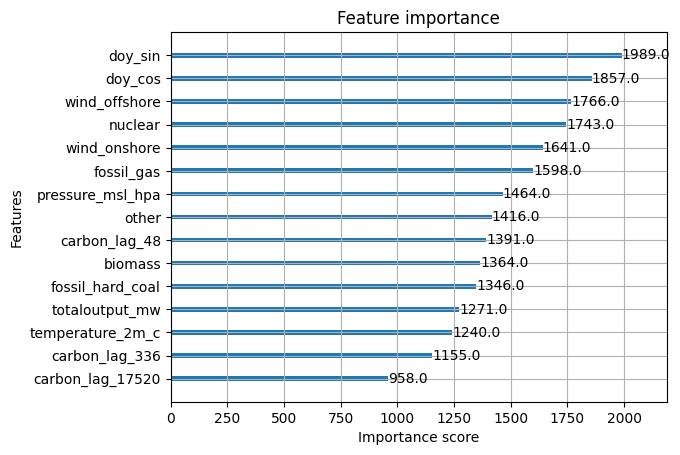

In [27]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model, max_num_features=15)
plt.show()